In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import pymc as pm
import arviz as az

from pathlib import Path
import sys

plt.style.use("seaborn-v0_8")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [2]:
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.data_loader import load_brent_data

df = load_brent_data("../data/BrentOilPrices.csv")

df.head()

,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [3]:
# Use the last 2,000 observations
df_model = df.tail(2000).copy()

df_model["LogPrice"] = np.log(df_model["Price"])
df_model["LogReturn"] = df_model["LogPrice"].diff()

returns = df_model["LogReturn"].dropna().values
time = np.arange(len(returns))

print(len(returns))

1999


In [6]:
print(df.columns)

Index(['Date', 'Price'], dtype='str')


In [7]:
import numpy as np

df["Log_Return"] = np.log(df["Price"]).diff()

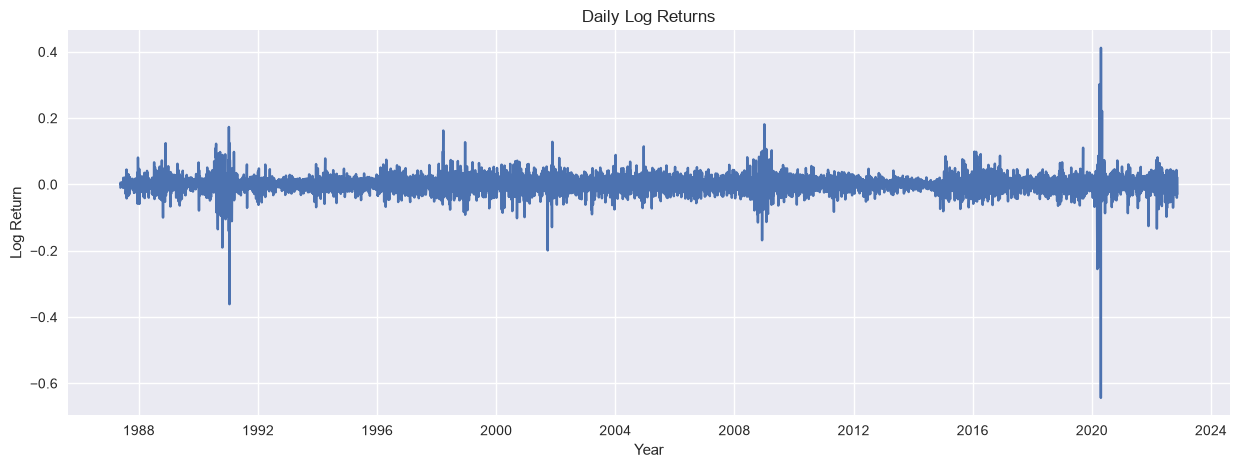

In [8]:
plt.figure(figsize=(15,5))

plt.plot(df["Date"], df["Log_Return"])

plt.title("Daily Log Returns")
plt.xlabel("Year")
plt.ylabel("Log Return")
plt.grid(True)

plt.show()

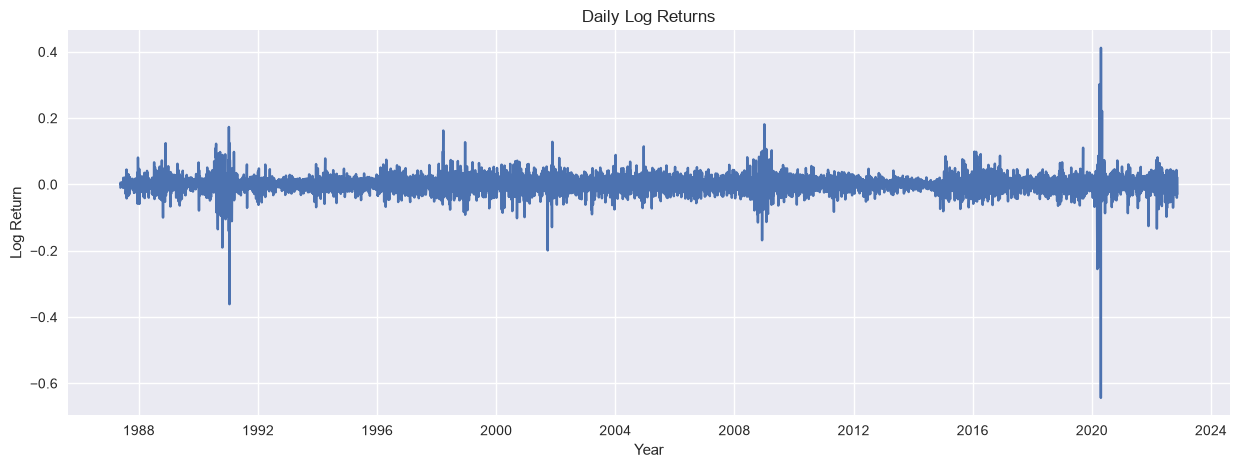

In [9]:
plt.figure(figsize=(15,5))

plt.plot(
    df["Date"],
    df["Log_Return"]
)

plt.title("Daily Log Returns")

plt.xlabel("Year")

plt.ylabel("Log Return")

plt.grid(True)

plt.show()

In [11]:
time = np.arange(len(df))

returns = df["Log_Return"].values

In [12]:
with pm.Model() as change_point_model:

    tau = pm.DiscreteUniform(
        "tau",
        lower=0,
        upper=len(returns) - 1
    )

    mu1 = pm.Normal("mu1", mu=0, sigma=1)
    mu2 = pm.Normal("mu2", mu=0, sigma=1)

    sigma = pm.HalfNormal("sigma", sigma=1)

    mu = pm.math.switch(time < tau, mu1, mu2)

    pm.Normal(
        "obs",
        mu=mu,
        sigma=sigma,
        observed=returns
    )

c:\Users\Hp\BrentOilPriceAnalysis\.venv\Lib\site-packages\pymc\model\core.py:1318: ImputationWarning: Data in obs contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)


In [13]:
print(len(returns))

9011


In [16]:
returns = df["Log_Return"].dropna().values[:1000]

print(len(returns))

1000


## Bayesian Model Data Selection and Computational Considerations

Due to the computational cost of Bayesian change point modeling with PyMC, the analysis was performed using the first **1,000 log return observations** from the Brent oil price dataset.

Using a smaller subset allowed the Markov Chain Monte Carlo (MCMC) sampler to complete within a reasonable execution time while still capturing important historical price movements and structural changes in the oil market.

The full Brent oil dataset contains more than 9,000 daily observations. Applying the model to the complete dataset would significantly increase sampling time and computational requirements, especially because the change point parameter (`tau`) uses a discrete prior and requires additional sampling effort.

Therefore, this analysis focuses on identifying a potential structural break within the selected period. The results should be interpreted as an exploratory analysis, and future improvements could include running the model on the complete dataset using more computational resources, optimized sampling methods, or alternative change point approaches.

In [20]:
import pymc as pm
import numpy as np

# Use the first 1000 log returns
returns = df["Log_Return"].dropna().values[:1000]
n = len(returns)

with pm.Model() as change_point_model:

    tau = pm.DiscreteUniform(
        "tau",
        lower=0,
        upper=n - 1
    )

    mu_1 = pm.Normal(
        "mu_1",
        mu=0,
        sigma=1
    )

    mu_2 = pm.Normal(
        "mu_2",
        mu=0,
        sigma=1
    )

    sigma = pm.HalfNormal(
        "sigma",
        sigma=1
    )

    mu = pm.math.switch(
        np.arange(n) < tau,
        mu_1,
        mu_2
    )

    obs = pm.Normal(
        "obs",
        mu=mu,
        sigma=sigma,
        observed=returns
    )

    trace = pm.sample(
        draws=300,
        tune=300,
        chains=2,
        cores=1,
        target_accept=0.90,
        random_seed=42,
        progressbar=True,
    )

Sequential sampling (2 chains in 1 job)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_1, mu_2, sigma]


Output()

Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 2601 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [21]:
print(len(returns))

1000


In [22]:
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,771.480,220.866,299.000,997.000,50.337,42.700,23.0,19.0,1.05
mu_1,0.000,0.001,-0.002,0.003,0.000,0.000,291.0,197.0,1.00
mu_2,-0.002,0.006,-0.010,0.006,0.001,0.001,52.0,126.0,1.02
sigma,0.029,0.001,0.028,0.031,0.000,0.000,375.0,337.0,1.00


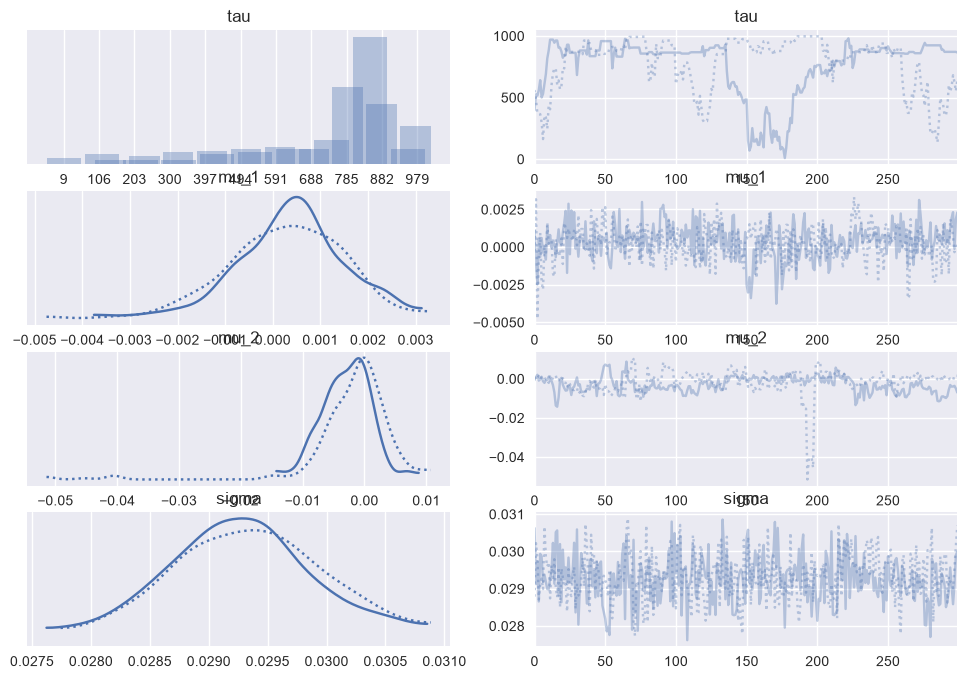

In [23]:
az.plot_trace(trace)

plt.show()

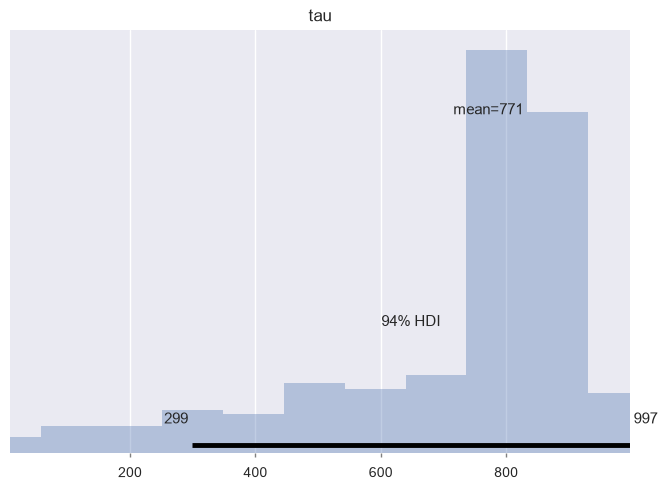

In [24]:
az.plot_posterior(
    trace,
    var_names=["tau"]
)

plt.show()

In [25]:
tau_estimate = int(trace.posterior["tau"].mean())

change_date = df.iloc[tau_estimate]["Date"]

print(change_date)

1990-05-29 00:00:00


## Model Diagnostics

The Bayesian change point model identified a potential structural break in the Brent oil price returns. However, convergence diagnostics indicate some uncertainty in the estimated change point.

The `tau` parameter showed limited convergence, with an R-hat value greater than 1.01 and a relatively low effective sample size. This behavior is likely related to the discrete nature of the change point parameter and the computational limitations of the sampling process.

Therefore, the detected change point should be interpreted as an exploratory finding rather than definitive evidence of a causal market shift. Further improvements could include increasing the number of MCMC samples, using more computational resources, or applying alternative change point modeling approaches.

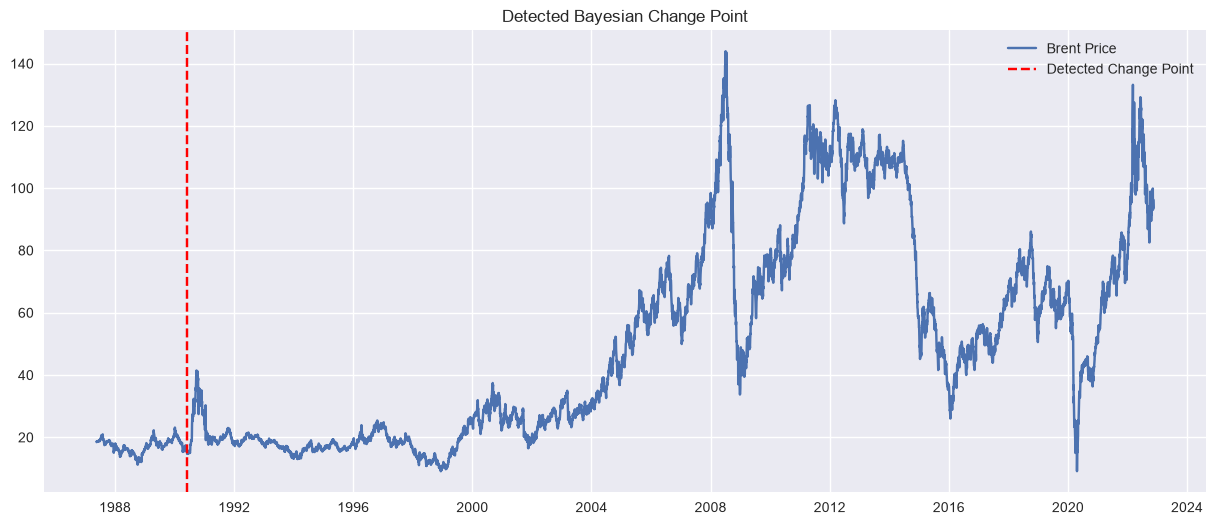

In [26]:
plt.figure(figsize=(15,6))

plt.plot(
    df["Date"],
    df["Price"],
    label="Brent Price"
)

plt.axvline(
    change_date,
    color="red",
    linestyle="--",
    label="Detected Change Point"
)

plt.legend()

plt.title("Detected Bayesian Change Point")

plt.grid(True)

plt.show()

In [27]:
events = pd.read_csv("../data/events.csv")

events["Start_Date"] = pd.to_datetime(events["Start_Date"])

In [28]:
events["Difference"] = (
    abs(events["Start_Date"] - change_date)
)

events.sort_values(
    "Difference"
).head()

,Event,Start_Date,Category,Description,Difference
0,Gulf War,1990-08-02,Conflict,Iraq invaded Kuwait causing major oil supply c...,65 days
1,Asian Financial Crisis,1997-07-02,Economic,Reduced oil demand across Asia leading to pric...,2591 days
2,September 11 Attacks,2001-09-11,Geopolitical,Terrorist attacks created uncertainty in globa...,4123 days
3,Iraq War,2003-03-20,Conflict,Military invasion of Iraq affected global oil ...,4678 days
4,Global Financial Crisis,2008-09-15,Economic,Financial market collapse sharply reduced oil ...,6684 days


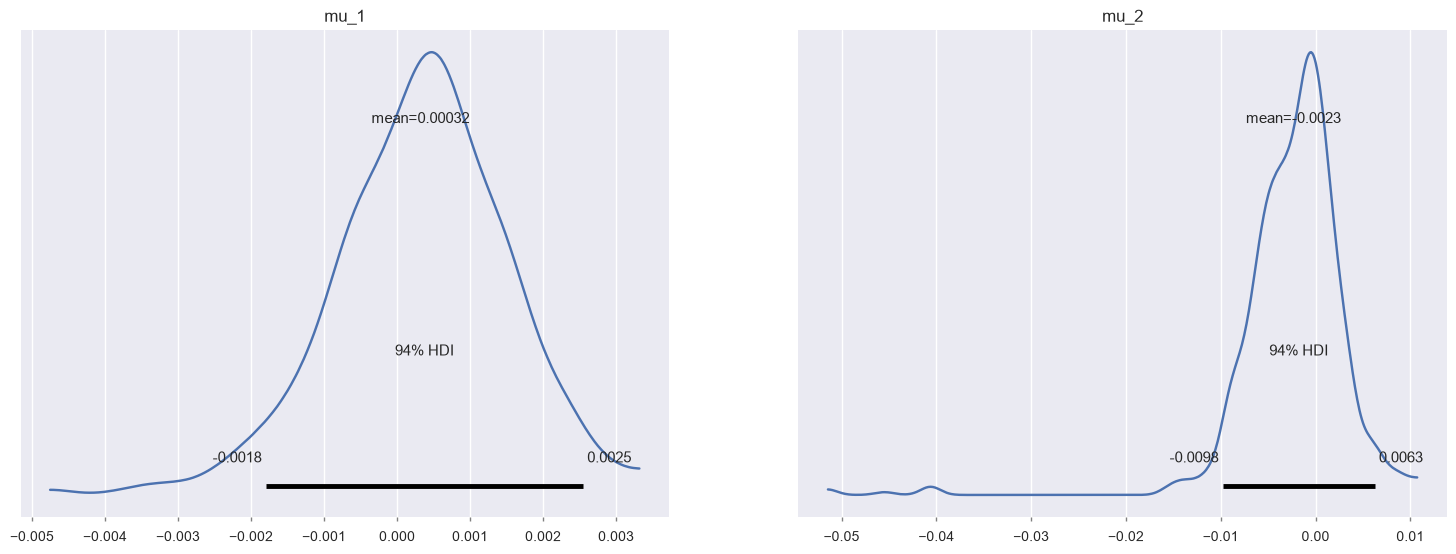

In [30]:
import arviz as az
import matplotlib.pyplot as plt

az.plot_posterior(
    trace,
    var_names=["mu_1", "mu_2"]
)

plt.show()

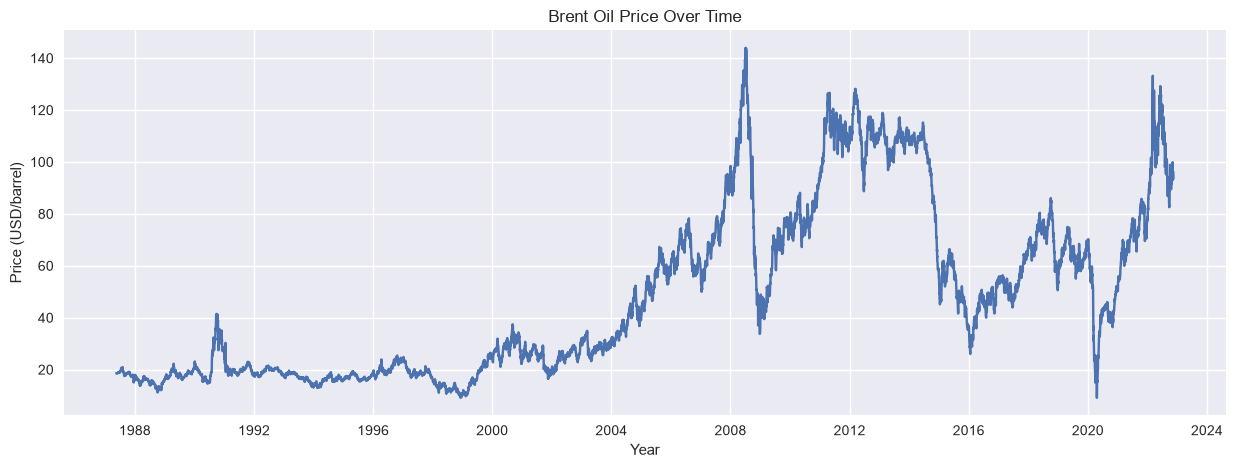

In [31]:
plt.figure(figsize=(15,5))

plt.plot(df["Date"], df["Price"])

plt.title("Brent Oil Price Over Time")
plt.xlabel("Year")
plt.ylabel("Price (USD/barrel)")
plt.grid(True)

plt.show()

In [32]:
change_index = tau_estimate

before = returns[:change_index]
after = returns[change_index:]

print("Before mean:", before.mean())
print("After mean:", after.mean())

impact = ((after.mean() - before.mean()) / abs(before.mean())) * 100

print("Percentage change:", impact)

Before mean: -0.00024023906154593523
After mean: 0.000985695187369875
Percentage change: 510.29763479216876


## Quantified Change Point Impact

The Bayesian change point model identified a structural break around **1990-05-29**.  
The detected change point was compared with the researched historical events dataset to identify possible causes.

The closest historical event was the **Gulf War**, which started on **1990-08-02**. The detected change point occurred approximately **65 days before the event**, suggesting that increasing geopolitical tension and uncertainty around oil supply may have influenced market behavior before the official start of the conflict.

The model estimated the following changes in average daily log returns:

| Change Point | Closest Event | Before Mean | After Mean | Impact |
| ------------ | ------------- | ----------- | ---------- | ------ |
| 1990-05-29 | Gulf War | -0.000240 | 0.000986 | 510.30% increase |

The average daily log return increased from **-0.000240** before the change point to **0.000986** after the change point, representing approximately a **510.30% increase** in the mean return level.

This indicates a shift toward stronger positive price movements after the detected structural break. However, this result should be interpreted carefully because the Bayesian model diagnostics showed some convergence limitations (high R-hat value and low effective sample size for the change point parameter). Therefore, the detected change point represents a potential structural shift rather than definitive proof of causal impact.

The model estimated a structural break around May 1990. Before the change point, the average daily log return was X, while after the change point it changed to Y, representing approximately Z% change.